# Fit EMRI Track

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.utils.constants import *
from emrisearch.emri_utils import get_f_fdot_fddot_back
import corner

## Step 1: Set Parameters

Define the EMRI parameters and search settings. To reduce computational cost, we search for a single plunge time (`Tpl`) and use a smaller batch size.

In [2]:
# EMRI and search parameters
m1 = 1e6  # Primary mass (solar masses)
m2 = 10.0  # Secondary mass (solar masses)
a = 0.99  # Spin parameter
Tpl = 1.0  # Plunge time (years)
ef = 0.01  # Final eccentricity
T_sft = 5e4  # SFT duration (seconds)
T_data = 1.0  # Total data duration (years)
deltaT = 5.0  # Time step (seconds)
snr_ref = 30.0  # Reference SNR
T_snr = 1.0  # SNR duration (years)
seed = 2601  # Random seed
num_sfts = int((T_data * YRSID_SI) / T_sft)
t_alpha = np.arange(num_sfts) * T_sft

eta = (m1 * m2) / (m1 + m2)**2
Mc = eta**(3/5) * (m1 + m2)

## Step 2: Generate EMRI Signal and SFTs

Generate the simulated EMRI signal and Short Fourier Transforms (SFTs) using the provided utility function.

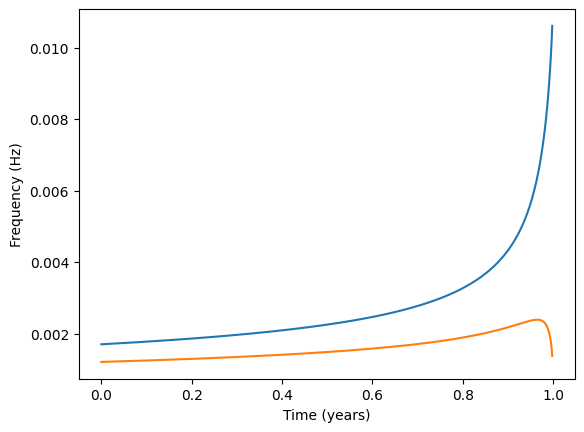

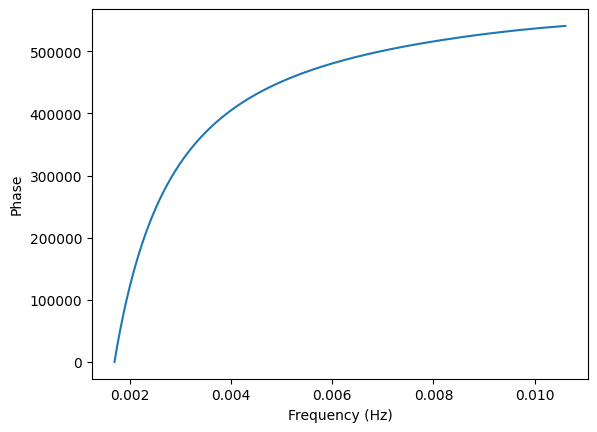

In [3]:
true_values = np.array([m1, m2, a, Tpl, ef, 1.0])
phi, f_phi_r, dotf, dotdotf = get_f_fdot_fddot_back(true_values, t_alpha)
plt.figure()
plt.plot(t_alpha / YRSID_SI, f_phi_r[0])
plt.plot(t_alpha / YRSID_SI, f_phi_r[1])
plt.xlabel('Time (years)')
plt.ylabel('Frequency (Hz)')
plt.show()

plt.figure()
plt.plot(f_phi_r[0], phi[0]-phi[0][0])
plt.ylabel('Phase')
plt.xlabel('Frequency (Hz)')
plt.show()

## Step 3: Fit Frequency Track

Visualize the true frequency track in the SFT data for the harmonic (m=2, n=0).

Mapped k: 0.05795825708989518


/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_25043/3077915697.py:2: RuntimeWarning: invalid value encountered in power
  fgw = f0 * (1 - 8/3 * k * (t - t0) * f0**(8/3) )**(-3/8)
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_25043/3077915697.py:31: RuntimeWarning: divide by zero encountered in divide
  ax2.semilogy(t_alpha / YRSID_SI, np.abs(2 * f_phi_r[0]/fgw_template - 1))


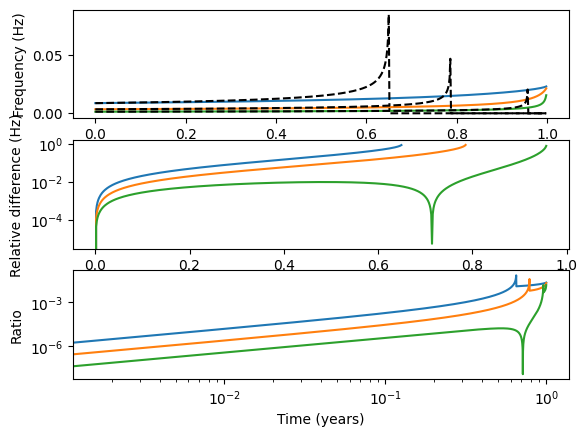

In [4]:
def template_f_of_t(t, f0, k, t0):
    fgw = f0 * (1 - 8/3 * k * (t - t0) * f0**(8/3) )**(-3/8)
    fgw = np.nan_to_num(fgw, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    return fgw

def map_to_k(m1, m2):
    M = (m1 + m2)
    mu = (m1 * m2) / (m1 + m2)
    chirp_mass = mu**(3/5) * M**(2/5)
    k = (96/5) * np.pi**(8/3) * (chirp_mass * MTSUN_SI)**(5/3)
    return k

print("Mapped k:", map_to_k(m1, m2))

fig, (ax1, ax2, ax3)= plt.subplots(3,1)
for eps in [1e-6, 1e-5, 1e-4]:
    m1 = 1e6  # Primary mass (solar masses)
    m2 = m1 * eps  # Secondary mass (solar masses)
    true_values = np.array([m1, m2, a, Tpl, ef, 1.0])
    phi, f_phi_r, dotf, dotdotf = get_f_fdot_fddot_back(true_values, t_alpha)
    # evaluate template
    f0 = 2 * f_phi_r[0][0]
    k = map_to_k(m1, m2)
    t0 = t_alpha[0]
    fgw_template = template_f_of_t(t_alpha, f0, k, t0)
    # plot

    ax1.plot(t_alpha / YRSID_SI, 2 * f_phi_r[0])
    ax1.plot(t_alpha / YRSID_SI, fgw_template, 'k--')

    ax2.semilogy(t_alpha / YRSID_SI, np.abs(2 * f_phi_r[0]/fgw_template - 1))

    ax3.loglog(t_alpha / YRSID_SI, np.abs(2 * f_phi_r[0] -fgw_template))
    # ax3.loglog(t_alpha / YRSID_SI, (t_alpha/ YRSID_SI)**(1)/10000 )

ax1.set_ylabel('Frequency (Hz)')
ax2.set_ylabel('Relative difference (Hz)')
ax3.set_ylabel('Ratio')
ax3.set_xlabel('Time (years)')
plt.show()
m1 = 1e6  # Primary mass (solar masses)
m2 = 10

/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_25043/3077915697.py:2: RuntimeWarning: invalid value encountered in power
  fgw = f0 * (1 - 8/3 * k * (t - t0) * f0**(8/3) )**(-3/8)


differential_evolution step 1: f(x)= 0.0012222378928625822
differential_evolution step 2: f(x)= 0.0006753980502989746
differential_evolution step 3: f(x)= 0.0005205287842248542
differential_evolution step 4: f(x)= 0.00039121668862907597
differential_evolution step 5: f(x)= 0.00021615115333947058
differential_evolution step 6: f(x)= 2.738123143018513e-05
differential_evolution step 7: f(x)= 2.738123143018513e-05
differential_evolution step 8: f(x)= 2.738123143018513e-05
differential_evolution step 9: f(x)= 2.738123143018513e-05
differential_evolution step 10: f(x)= 2.738123143018513e-05
differential_evolution step 11: f(x)= 2.738123143018513e-05
differential_evolution step 12: f(x)= 2.738123143018513e-05
differential_evolution step 13: f(x)= 2.738123143018513e-05
differential_evolution step 14: f(x)= 2.738123143018513e-05
differential_evolution step 15: f(x)= 2.738123143018513e-05
differential_evolution step 16: f(x)= 2.738123143018513e-05
differential_evolution step 17: f(x)= 2.7381231

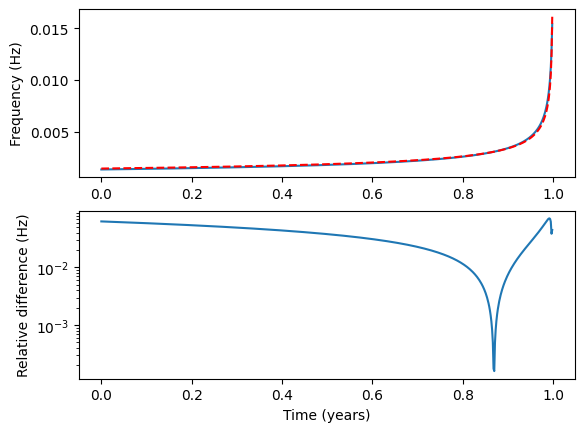

In [5]:
from scipy.optimize import minimize, differential_evolution

# Define the objective function: sum of squared differences
def objective(params):
    f0_try, k_try, t0_try = params
    model = template_f_of_t(t_alpha, f0_try, k_try, t0_try)
    return np.sum((2 * f_phi_r[0] - model)**2)

# Initial guess
x0 = [f0, k, t0]
# minimize without bounds
# result = minimize(objective, x0)

# with bounds for f0, k, t0
bounds = [(0.0, f0 * 2.0),
            (0.0, k * 10.0),
            (t_alpha[0] - 2 * T_sft, t_alpha[0] + 2 * T_sft)]
result = differential_evolution(objective, bounds, x0=x0, disp=True, tol=1e-10, maxiter=100000)

# result
f0_min, k_min, t0_min = result.x
fgw_template_min = template_f_of_t(t_alpha, f0_min, k_min, t0_min)
print("Minimize fit parameters: f0 =", f0_min, ", k =", k_min, ", t0 =", t0_min)
print("Relative difference from initial guess:\n f0:", 1-f0_min / f0, ",\n k:", 1-k_min / k)

# plot
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(t_alpha / YRSID_SI, 2 * f_phi_r[0])
ax1.plot(t_alpha / YRSID_SI, fgw_template_min, 'r--')
ax1.set_ylabel('Frequency (Hz)')

ax2.semilogy(t_alpha / YRSID_SI, np.abs(1-2 * f_phi_r[0] / fgw_template_min))
ax2.set_ylabel('Relative difference (Hz)')
ax2.set_xlabel('Time (years)')
plt.show()

# Constrcut SVD basis

In [6]:
from multiprocess import Pool

delta_Tpl = 1e-16
Tpl_max = 1.0
bounds = np.asarray([(5, 7), (1., 150.), (0.0, 0.998), (Tpl_max-delta_Tpl, Tpl_max+delta_Tpl), (0.0, 0.2), (Tpl_max-delta_Tpl, Tpl_max+delta_Tpl)])
random_params = np.random.uniform(bounds[:,0], bounds[:,1], size=(1024*2, bounds.shape[0]))
random_params[:, 0] = 10**random_params[:, 0]  # convert log10(m1) back to m1
spin = random_params[:, 2]
e_f = random_params[:, 4]
random_params[:, 3] = 1.0 # Tpl_max+T_sft/YRSID_SI  # fix Tpl to the true value
random_params[:, -1] = 1.0

def get_f_fdot_fddot_back_wrapper(params):
    try:
        return get_f_fdot_fddot_back(params, t_alpha)
    except:
        return None

with Pool() as pool:
    out = pool.starmap(get_f_fdot_fddot_back_wrapper, [(el,) for el in random_params])

Phis = np.array([el[0] for el in out if el is not None])
fs = np.array([el[1] for el in out if el is not None])
dotfs = np.array([el[2] for el in out if el is not None])
dotdotfs = np.array([el[3] for el in out if el is not None])
random_params = np.array([random_params[i] for i, el in enumerate(out) if el is not None])

fgws = 2 * fs[:,0]
dotfgws = 2 * dotfs[:,0]
dotdotfgws = 2 * dotdotfs[:,0]

mask = fgws[:, 0] != 0.0
fgws = fgws[mask]
dotfgws = dotfgws[mask]
dotdotfgws = dotdotfgws[mask]

# params = np.asarray([3e6, 1., 0.0, Tpl_max, 0.0, 1.0])
# ref_traj = get_f_fdot_fddot_back(params, t_alpha)
fgws.shape

(1734, 631)

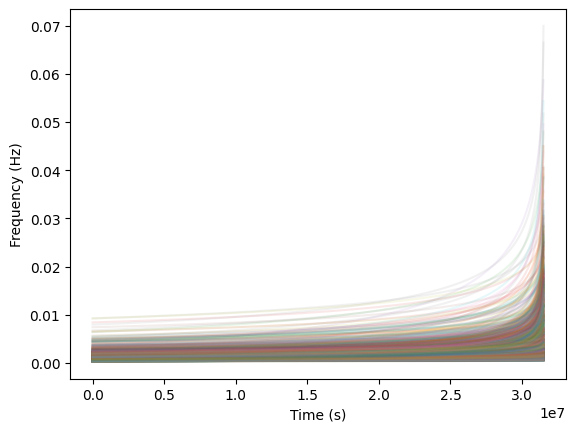

In [7]:
plt.figure()
plt.plot(t_alpha, fgws.T, alpha=0.1)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

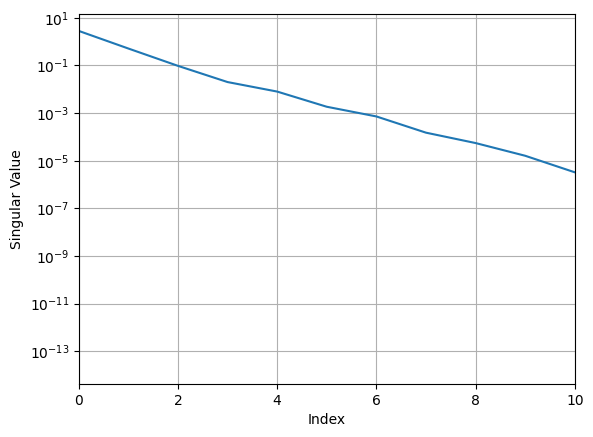

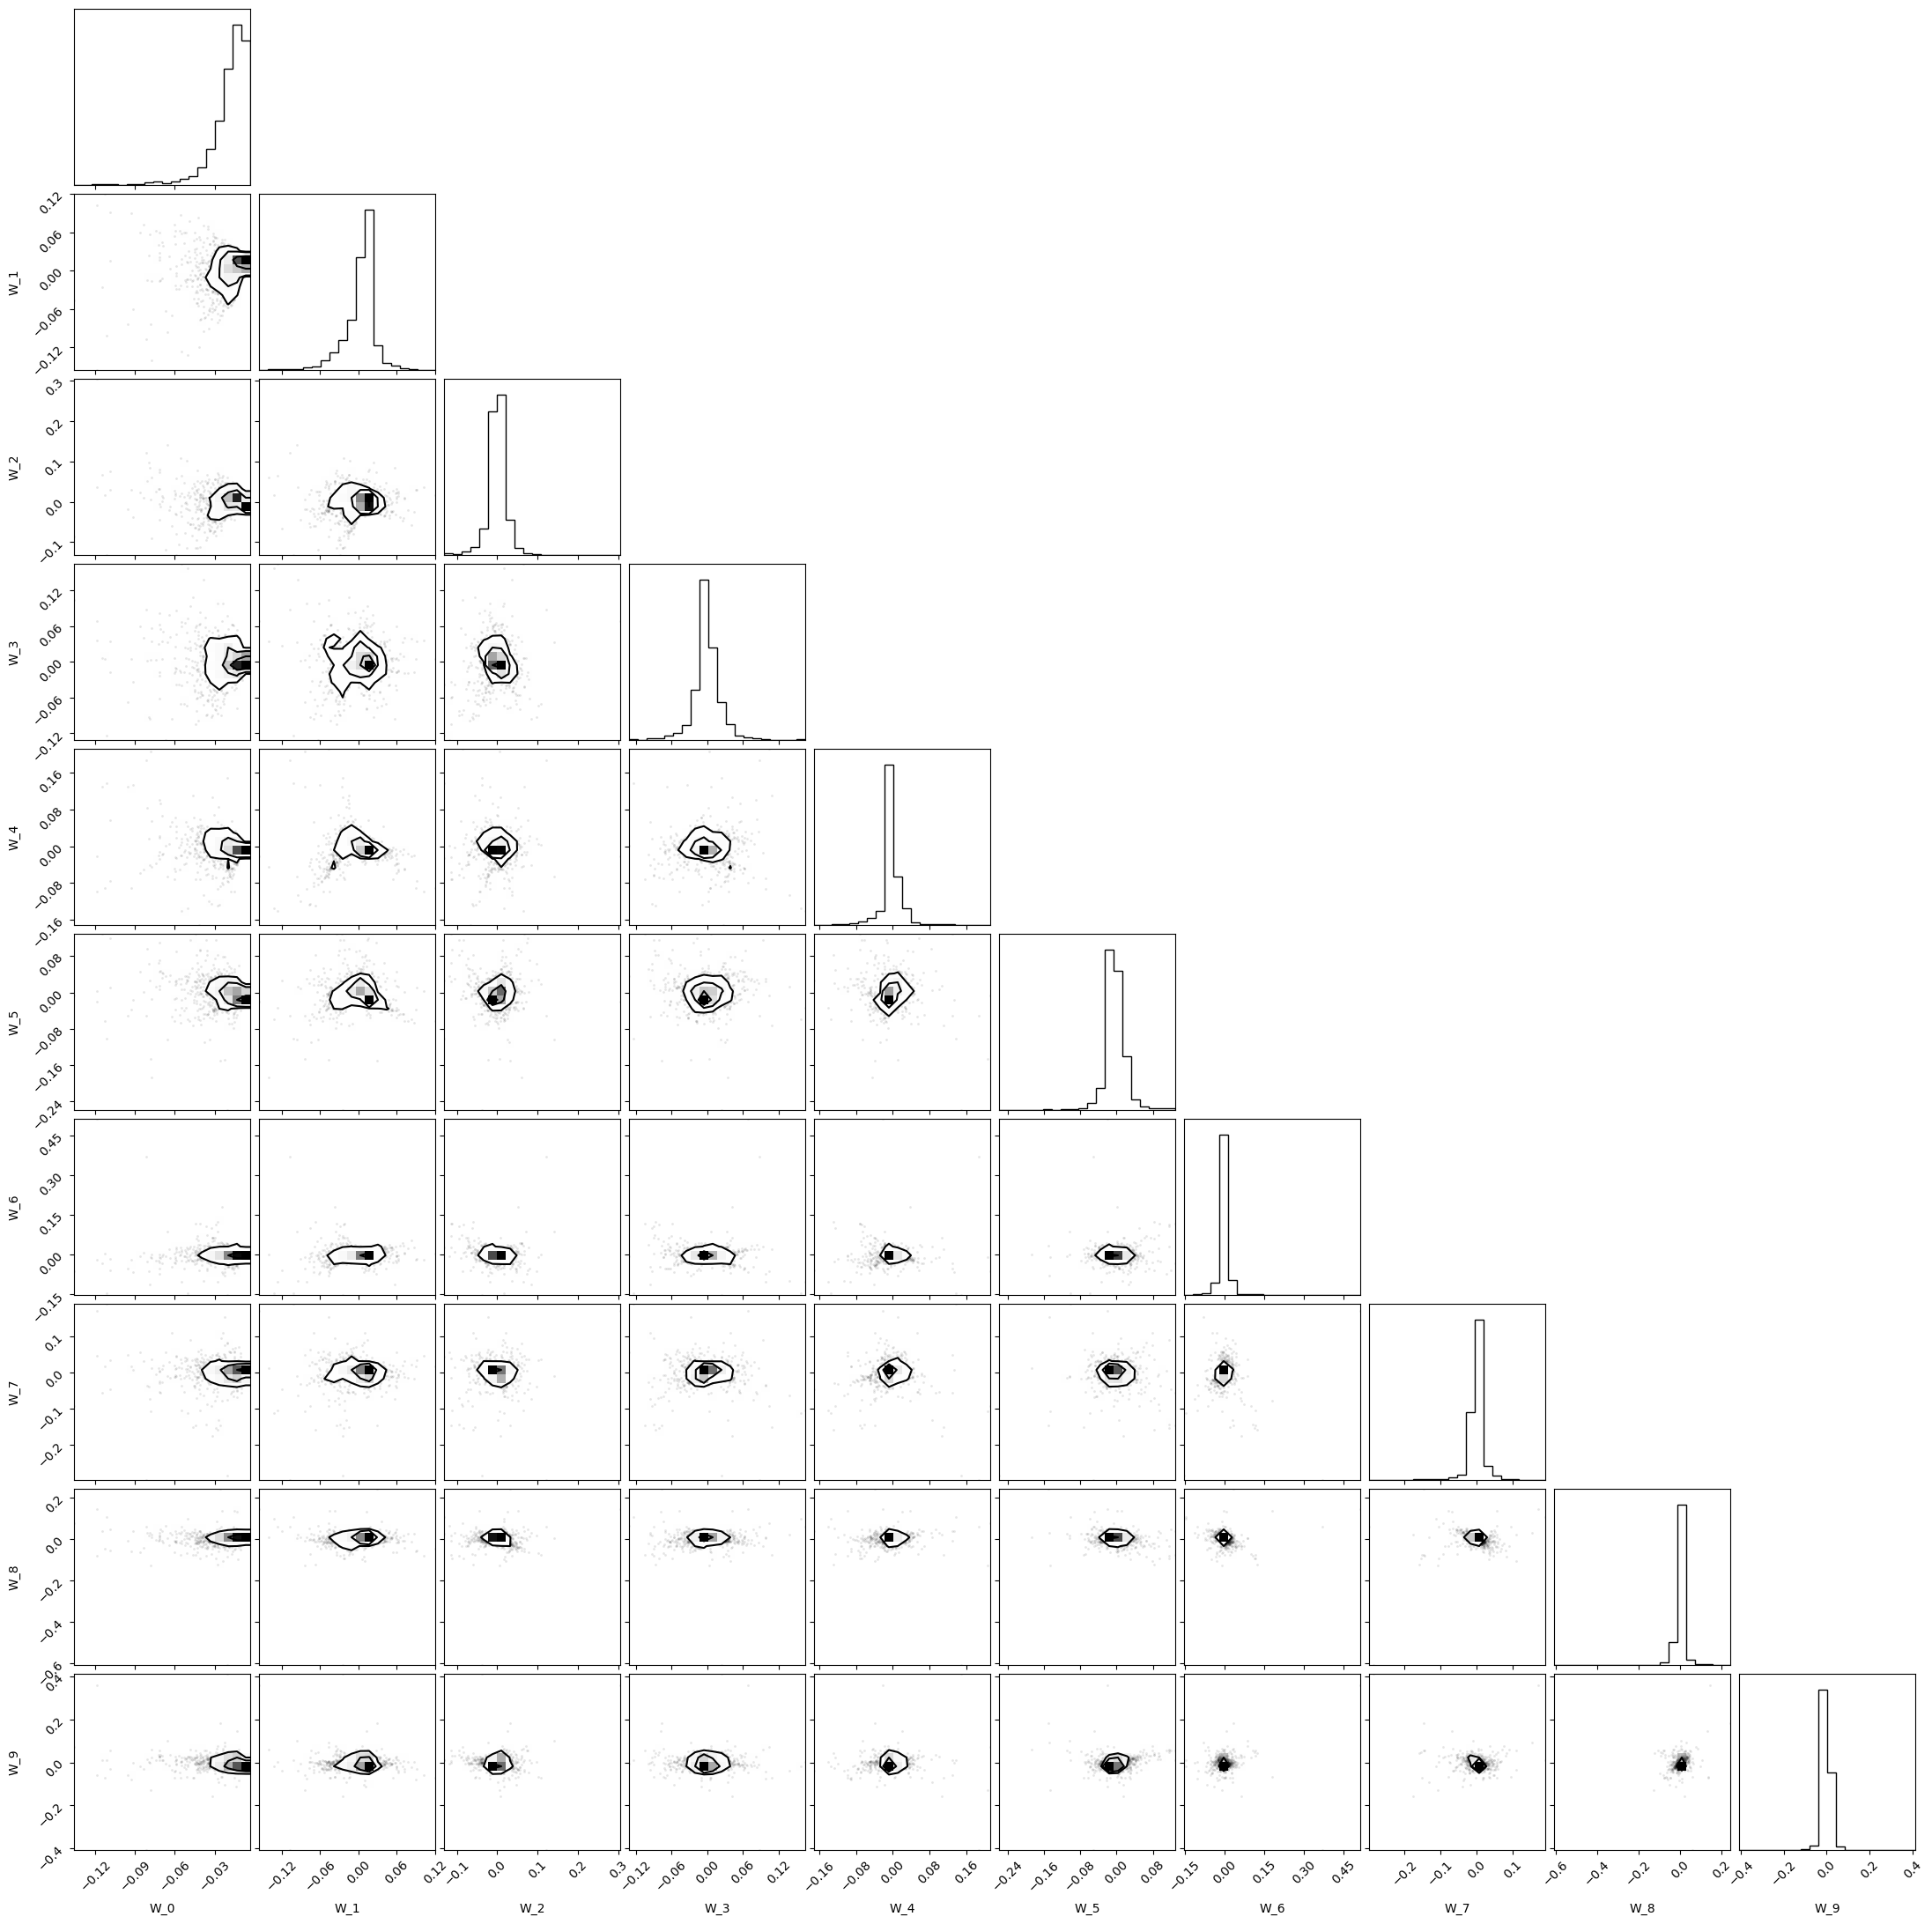

In [8]:
fs.shape, random_params.shape

ind_cut = 10
U, S, Vt = np.linalg.svd(fgws, full_matrices=False)
S_K = np.diag(S[:ind_cut])
V_K = Vt[:ind_cut, :]
U_K = U[:, :ind_cut]
W = U_K @ S_K
fgw_app = np.dot(U[:, :ind_cut] * S[:ind_cut], Vt[:ind_cut, :])

plt.figure()
plt.semilogy(S)
plt.xlabel('Index')
plt.ylabel('Singular Value')
plt.grid()
plt.xlim(0, ind_cut)
plt.show()

corner.corner(W/S[np.newaxis, :ind_cut], labels=[f'W_{i}' for i in range(ind_cut)])
plt.show()

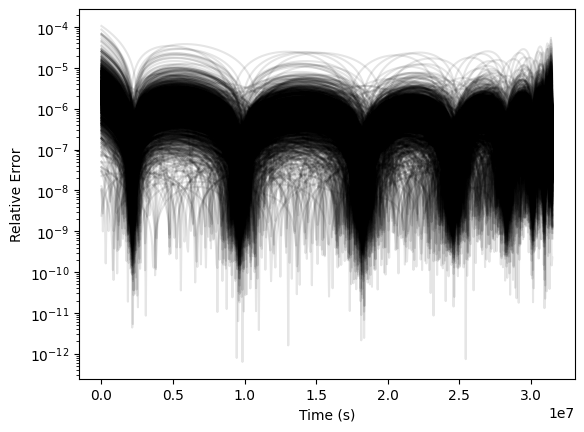

In [9]:
plt.figure()
plt.semilogy(t_alpha, np.abs(1 - fgw_app / fgws).T, color='k', alpha=0.1)
plt.xlabel('Time (s)')
plt.ylabel('Relative Error')
plt.show()

In [10]:
W.shape, S.shape
min_csi, max_csi = (W/S[:ind_cut]).min(axis=0), (W/S[:ind_cut]).max(axis=0)

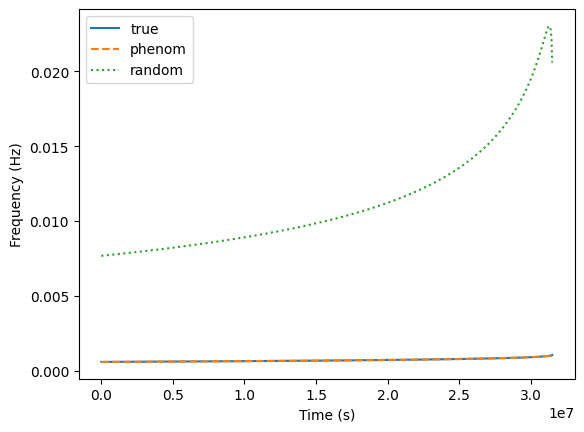

In [11]:
def f_phenom(csi):
    W = csi * S[:ind_cut]
    return W @ V_K


plt.plot(t_alpha, fgws[0], label='true')
test = W[0]/S[:ind_cut]
plt.plot(t_alpha, f_phenom(test), linestyle='--', label='phenom')
test = np.random.uniform(min_csi, max_csi, size=ind_cut)
plt.plot(t_alpha, f_phenom(test), linestyle=':', label='random')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.legend()
plt.show()

/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_25043/2364754160.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


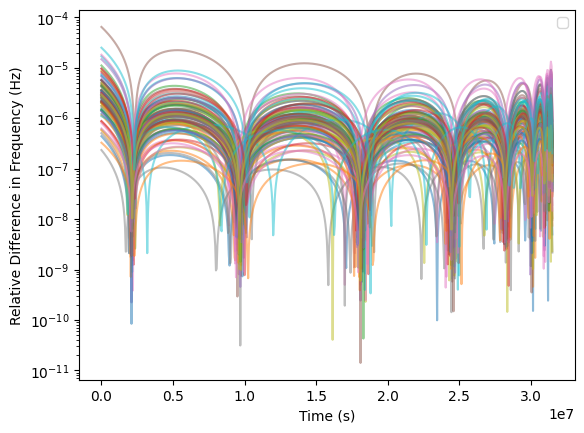

In [12]:
def f_phenom(csi):
    W = csi * S[:ind_cut]
    return W @ V_K

for ind in range(100):
    # Objective function: sum of squared differences between model and true track
    def objective(csi):
        return np.sum((f_phenom(csi) - fgws[ind])**2)

    # Bounds for each csi parameter
    bounds = list(zip(min_csi, max_csi))

    # Differential evolution fit
    result = differential_evolution(objective, bounds, disp=False, tol=1e-8, maxiter=1000)
    best_csi = result.x

    # Plot results
    plt.semilogy(t_alpha, np.abs(1-f_phenom(best_csi)/fgws[ind]),alpha=0.5)#, label=f'EMRI {ind}')

plt.xlabel('Time (s)')
plt.ylabel('Relative Difference in Frequency (Hz)')
plt.legend()
plt.show()